# **Epoch-wise Deep Double Descent Demonstration**

**_Author: Prathamesh Pradeep Jadhav_**

- This notebook demonstrates the phenomena of epoch-wise deep double descent in multi-label classification setting.
- Clinical PTBXL dataset was employed.
- For all the multi-hot encoded labels, dfault noise was set at 15%.
- SGD as an optimiser for better display of phenomena.
- Simple conv1D resnet model was trained for 400 epochs.
- Important metrics include: BCE loss, Binary Accuracy and Hamming Loss

## Import Essential Modules and Set Initial Configuration Variables

In [ ]:
# Import Essential Modules
import wfdb
import ast
import pickle
import datetime
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from keras import layers
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split

# config trail runs
PTBXL_PATH = "/home/student/Prathamesh's Project Pre-requisites/DataRes/physionet.org/files/ptb-xl/1.0.3/" # path to PTB-XL dataset
SAMPLING_RATE = 100 
NUM_CLASSES = 5
NOISE_RATE = 0.15 # 15% label noise (default) key for double descent
NUM_EPOCHS = 400
BATCH_SIZE = 64
SUBSET_SIZE = 3000 # small to easier interpolation
WIDTH = 64 # default width for epoch wise double descent

2026-03-02 09:04:51.702664: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-02 09:04:51.721239: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-02 09:04:52.376331: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Import Data and Add Label Noise

In [3]:
# Load data
def load_ptbxl(path, sampling_rate=100):
    Y = pd.read_csv(path + 'ptbxl_database.csv', index_col='ecg_id')
    Y.scp_codes = Y.scp_codes.apply(ast.literal_eval)

    agg_df = pd.read_csv(path + 'scp_statements.csv', index_col=0)
    agg_df = agg_df[agg_df.diagnostic == 1.0]

    def aggregate_diagnostic(y_dic):
        tmp = set()
        for key in y_dic.keys():
            if key in agg_df.index:
                tmp.add(agg_df.loc[key].diagnostic_class)
            return list(tmp)

    Y['diagnostic_superclass'] = Y.scp_codes.apply(aggregate_diagnostic)

    # Keep only samples that have at least one diagnostic superclass
    Y = Y[Y['diagnostic_superclass'].map(len) >= 1]

    # Get top 5 classes
    from collections import Counter
    all_labels = [label for sublist in Y['diagnostic_superclass'] for label in sublist]
    top5 = [label for label, _ in Counter(all_labels).most_common(5)]
    print(f"Top 5 classes: {top5}")

    # Filter to samples that have at least one top-5 label
    Y['diagnostic_superclass'] = Y['diagnostic_superclass'].apply(
    lambda x: [l for l in x if l in top5]
    )
    Y = Y[Y['diagnostic_superclass'].map(len) >= 1]

    # Multi-hot encode
    mlb = MultiLabelBinarizer(classes=top5)
    y = mlb.fit_transform(Y['diagnostic_superclass']) # (N, 5) binary matrix

    # Load signals
    filenames = Y.filename_lr if sampling_rate == 100 else Y.filename_hr
    print("Loading signals...")
    X = np.array([wfdb.rdsamp(path + f)[0] for f in filenames]) # (N, 1000, 12)

    return X, y, top5, mlb

In [4]:
# Add label noise

def add_label_noise(y, noise_rate, seed=42):
    # random flip of entries
    rng = np.random.default_rng(seed)
    y_noisy = y.copy().astype(float)
    mask = rng.random(y_noisy.shape) < noise_rate # flip each entry independently
    y_noisy[mask] = 1.0 - y_noisy[mask] # 0 to 1 or 1 to 0
    return y_noisy

## Over-parameterised Model Creation

A model with extreme numbers of parameters was created in order to fit the subseted data and display suitable results.

In [5]:
# Conv1D+BiLSTM Model

# residual block
def residual_block(x, filters, kernel_size = 3, stride=1):
    shortcut = x
    
    # main path
    x = layers.Conv1D(filters, kernel_size, strides = stride, padding = "same", use_bias = False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv1D(filters, kernel_size, strides = stride, padding = "same", use_bias = False)(x)
    x = layers.BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, kernel_size = 1, strides = stride, use_bias = False)(shortcut)
    shortcut = layers.BatchNormalization()(shortcut)

    # skip-connection
    x = layers.Add()([shortcut, x])
    x = layers.ReLU()(x)
    return x

def build_model(input_shape = (1000, 12), num_classes = 5, width = 64):
    # Input layers
    InputLayer = layers.Input(shape=input_shape)

    # 1D-CNN Block 1
    x = layers.Conv1D(width, kernel_size = 7, strides = 2, padding = "same", use_bias = False)(InputLayer)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # residual block 1
    x = residual_block(x, width)
    # residual block 2
    x = residual_block(x, width)
    # residual block 3
    x = residual_block(x, width)
    # residual block 4
    x = residual_block(x, width)
    # residual block 5
    x = residual_block(x, width)
    # residual block 6
    x = residual_block(x, width)

    # Bi-LSTM Block 1
    x = layers.Bidirectional(layers.LSTM(units = 128, return_sequences = True))(x)
    x = layers.Bidirectional(layers.LSTM(units = 128, return_sequences = False))(x)

    # Classification Overhead
    OutputLayer = layers.Dense(num_classes, activation = "sigmoid")(x)

    # Model Creation
    return tf.keras.Model(inputs = InputLayer, outputs = OutputLayer, name = "1DCNN_BiLSTM_Z_Model")

## Subclass Custom Metric : Hamming Loss

In [6]:
# Define custom metrics

# subclass custom Hamming Loss metric (Not using tensorflow addons here; version clash)
@tf.keras.utils.register_keras_serializable()
class HammingLoss(tf.keras.metrics.Metric):

    def __init__(self, name = "Hamming_loss", **kwargs):
        super(HammingLoss, self).__init__(name = name, **kwargs)
        self.total_mismatches = self.add_weight(name = "Total_mismatches", initializer = 'zeros', dtype = tf.float32)
        self.total_labels = self.add_weight(name = "Total_labels", initializer = 'zeros', dtype = tf.float32)

    def update_state(self, y_true, y_pred, sample_weight=None):
        # caste predictions and targets in tf.float32
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(tf.greater(y_pred, 0.5), tf.float32)

        # Calculate mismatches
        mismatches = tf.cast((tf.math.count_nonzero(tf.math.not_equal(y_true, y_pred), axis=-1)), tf.float32)

        # Find number of labels and batch size
        num_label = tf.cast(tf.shape(y_true)[-1], tf.float32) # shape is (rows, columns) and columns = number of elements in array
        batch_size = tf.cast(tf.shape(y_true)[0], tf.float32) # shape is (rows, columns) and rows = batch size per array
        
        # Update number of mismatches and total labels count
        self.total_mismatches.assign_add(tf.reduce_sum(mismatches)) # reduce sum adds all the elements in an array (here, instance)
        self.total_labels.assign_add(batch_size * num_label) # total label count = number of labels x batch size per instance

    def result(self):
        return self.total_mismatches / self.total_labels # Hamming Loss formula
    
    def reset_state(self): # reset atttributes
        self.total_mismatches.assign(0.)
        self.total_labels.assign(0.)

## Define Custom Callbacks to Track Metrics Periodically

In [7]:
# Custom callback save metrics in a list
class EpochHistory(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.train_losses = []
        self.val_losses = []
        self.val_hl = []
        self.val_acc = []

    def on_epoch_end(self, epoch, logs=None):
        self.train_losses.append(logs['loss'])
        self.val_losses.append(logs['val_loss'])
        self.val_hl.append(logs['val_Hamming_loss'])
        self.val_acc.append(logs['val_acc'])

        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1} | train_loss={logs['loss']:.4f} "
                f"val_loss={logs['val_loss']:.4f} val_Hamming_loss={logs['val_Hamming_loss']:.4f} val_acc={logs['val_acc']:.4f}")


## Training Run

In [8]:
def run_experiment(noise_rate=0.15, width=64, subset_size=3000, epochs=400):
    # Load data
    X, y, classes, mlb = load_ptbxl(PTBXL_PATH, SAMPLING_RATE)
    print(f"Loaded {len(X)} samples, classes: {classes}")
    print(f"Label matrix shape: {y.shape}") # (N, 5)

    # Subset
    rng = np.random.default_rng(0)
    idx = rng.choice(len(X), size=min(subset_size, len(X)), replace=False)
    X, y = X[idx], y[idx]

    # Normalize per-lead
    X = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-8)

    # Train/test split use stratify on most frequent single label as proxy
    dominant_label = y.argmax(axis=1)
    X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=dominant_label, random_state=42
    )

    # Add label noise to training set only
    y_train_noisy = add_label_noise(y_train, noise_rate)
    flipped = (y_train_noisy != y_train).sum()
    print(f"Noise rate: {noise_rate} | Flipped entries: {flipped}/{y_train.size}")

    # build the model
    model = build_model(
    input_shape=(X_train.shape[1], X_train.shape[2]),
    num_classes=len(classes),
    width=width
    )

    # get summary and paras
    model.summary()

    # No weight decay important for double descent to emerge
    optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)

    # compile the model
    model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
    tf.keras.metrics.AUC(multi_label=True, name='auc'),
    tf.keras.metrics.BinaryAccuracy(name='acc'),
    HammingLoss()
    ]
    )

    # Cosine LR decay
    lr_scheduler = tf.keras.callbacks.LearningRateScheduler(
    lambda epoch: 0.01 * 0.5 * (1 + np.cos(np.pi * epoch / epochs))
    )

    history_cb = EpochHistory()

    # train
    model.fit(
    X_train, y_train_noisy,
    validation_data=(X_test, y_test), # evaluate on clean test labels
    epochs=epochs,
    batch_size=BATCH_SIZE,
    callbacks=[history_cb, lr_scheduler],
    verbose=0
    )

    return history_cb

In [8]:
# Run
history = run_experiment(noise_rate=0.15, width=64, subset_size=3000, epochs=400)

Top 5 classes: ['NORM', 'MI', 'STTC', 'CD', 'HYP']
Loading signals...
Loaded 21365 samples, classes: ['NORM', 'MI', 'STTC', 'CD', 'HYP']
Label matrix shape: (21365, 5)
Noise rate: 0.15 | Flipped entries: 1794/12000


Model: "1DCNN_BiLSTM_Z_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1000, 12)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 500, 64)   │      5,376 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 500, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 500, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 500, 64)   │     12,288 │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 64)   │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 500, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 500, 64)   │     12,288 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 64)   │        256 │ re_lu[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 64)   │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 500, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 500, 64)   │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 500, 64)   │     12,288 │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 64)   │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 500, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 500, 64)   │     12,288 │ re_lu_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 64)   │        256 │ re_lu_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 64)   │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 500, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 500, 64)   │          0 │ add_1[0][0]     

 Total params: 750,853 (2.86 MB)

 Trainable params: 748,421 (2.85 MB)

 Non-trainable params: 2,432 (9.50 KB)

2026-02-27 10:27:13.531967: E tensorflow/core/util/util.cc:131] oneDNN supports DT_BOOL only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


Epoch 50 | train_loss=0.1143 val_loss=0.7342 val_Hamming_loss=0.2463 val_acc=0.7537
Epoch 100 | train_loss=0.0016 val_loss=1.0178 val_Hamming_loss=0.2243 val_acc=0.7757
Epoch 150 | train_loss=0.0094 val_loss=1.0387 val_Hamming_loss=0.2460 val_acc=0.7540
Epoch 200 | train_loss=0.0007 val_loss=1.1305 val_Hamming_loss=0.2227 val_acc=0.7773
Epoch 250 | train_loss=0.0005 val_loss=1.1844 val_Hamming_loss=0.2213 val_acc=0.7787
Epoch 300 | train_loss=0.0005 val_loss=1.1994 val_Hamming_loss=0.2207 val_acc=0.7793
Epoch 350 | train_loss=0.0004 val_loss=1.2084 val_Hamming_loss=0.2227 val_acc=0.7773
Epoch 400 | train_loss=0.0004 val_loss=1.2080 val_Hamming_loss=0.2223 val_acc=0.7777


## Plotting and Representation

In [25]:
# plot edd mlc
def plot_double_descent(history, title_suffix=''):
    epochs = range(1, len(history.train_losses) + 1)
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 8), sharex=True)

    ax1.plot(epochs, history.train_losses, label='Train Loss', color='steelblue', alpha=0.8)
    ax1.plot(epochs, history.val_losses, label='Val Loss', color='tomato', linewidth=2)
    peak_epoch = np.argmax(history.val_losses) + 1
    ax1.axvline(peak_epoch, color='gray', linestyle='--', alpha=0.6)
    ax1.set_ylabel('Binary Crossentropy Loss')
    ax1.set_title(f'Epoch-wise Deep Double Descent on PTB-XL {title_suffix}')
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(epochs, history.val_acc, label='Val Binary Accuracy', color='seagreen', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(alpha=0.3)

    ax3.plot(epochs, history.val_hl, label = 'Val Hamming Loss', color = 'violet', linewidth = 2)
    peak_epoch_hl = np.argmax(history.val_hl) + 1
    ax3.axvline(peak_epoch_hl, color='gray', linestyle='--', alpha=0.6)
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Hamming Loss')
    ax3.legend()
    ax3.grid(alpha = 0.3)
    
    plt.tight_layout()
    plt.savefig('double_descent_multilabel.png', dpi=150)
    plt.show()

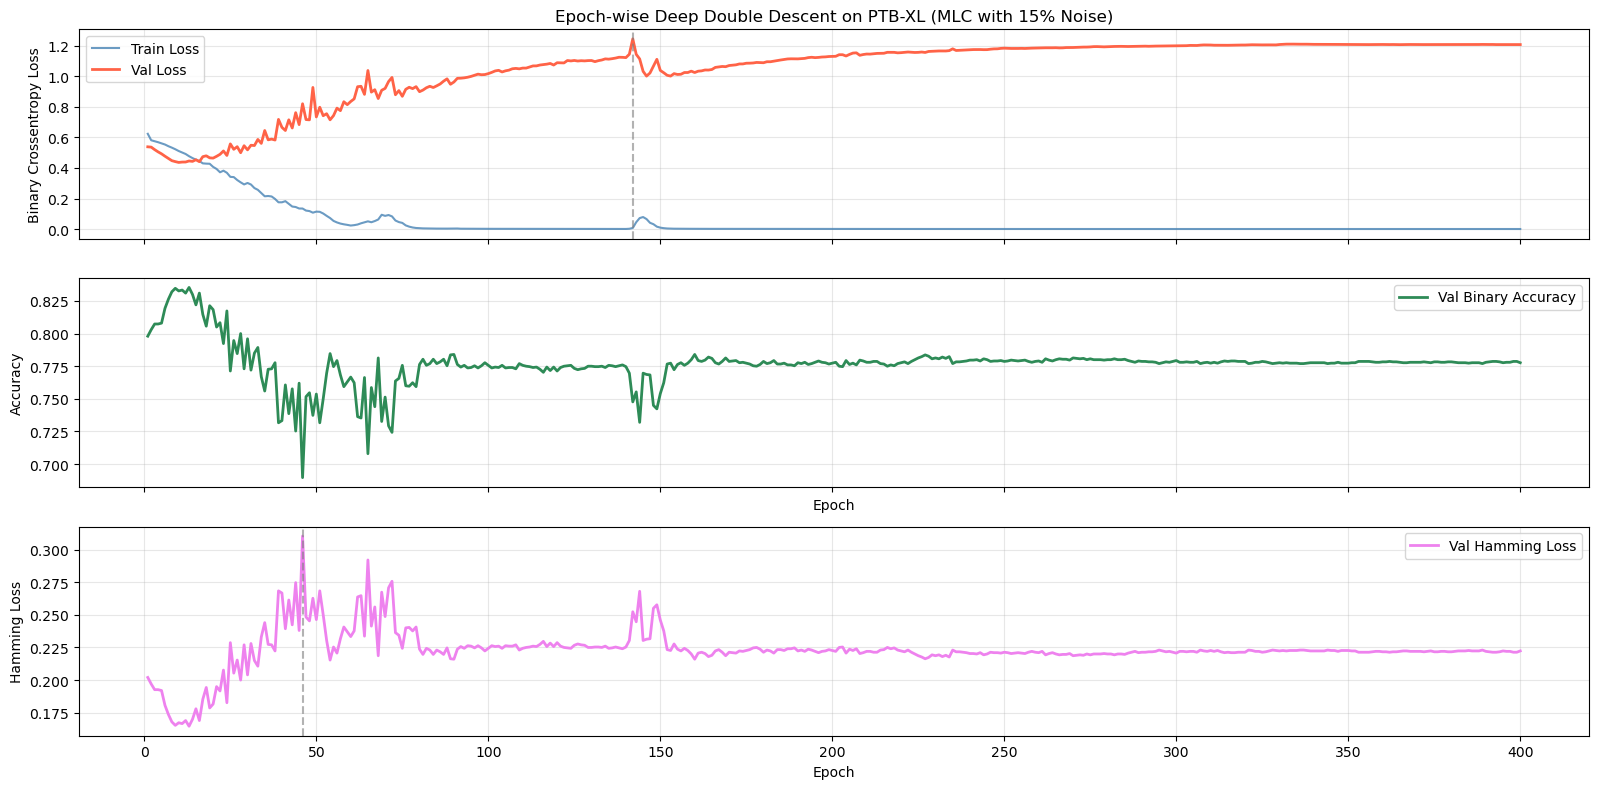

In [26]:
plot_double_descent(history=history, title_suffix = "(MLC with 15% Noise)")

In [ ]:
# create heatmaps
def plot_heatmap(history, title_suffix = ""):
    epochs = range(1, len(history.train_losses) + 1)
    fig, (ax1, ax2, ax3)= plt.subplots(1, 3, figsize=(16, 8), sharex=True)

    # Heatmap for train loss per epoch
    sns.heatmap(pd.DataFrame(history.train_losses, epochs), cmap = "mako",ax = ax1)
    ax1.set_xlabel("Train Loss")
    ax1.set_ylabel("Epochs")
    ax1.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    epoch_sparse = np.arange(0, 400, 50)
    ax1.set_yticks(epoch_sparse)
    ax1.set_yticklabels(epoch_sparse)

    # Heatmap for evaluation loss per epoch
    sns.heatmap(pd.DataFrame(history.val_losses, epochs), cmap = "mako",ax = ax2)
    ax2.set_xlabel("Test Loss")
    ax2.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax2.set_yticks(epoch_sparse)
    ax2.set_yticklabels(epoch_sparse)
    ax2.set_title(f"Epoch-wise Deep Double Descent {title_suffix}")

    # Heatmap for hamming loss per epoch
    sns.heatmap(pd.DataFrame(history.val_hl, epochs), cmap = "mako",ax = ax3)
    ax3.set_xlabel("Hamming Loss")
    ax3.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax3.set_yticks(epoch_sparse)
    ax3.set_yticklabels(epoch_sparse)

    plt.tight_layout()
    plt.show()

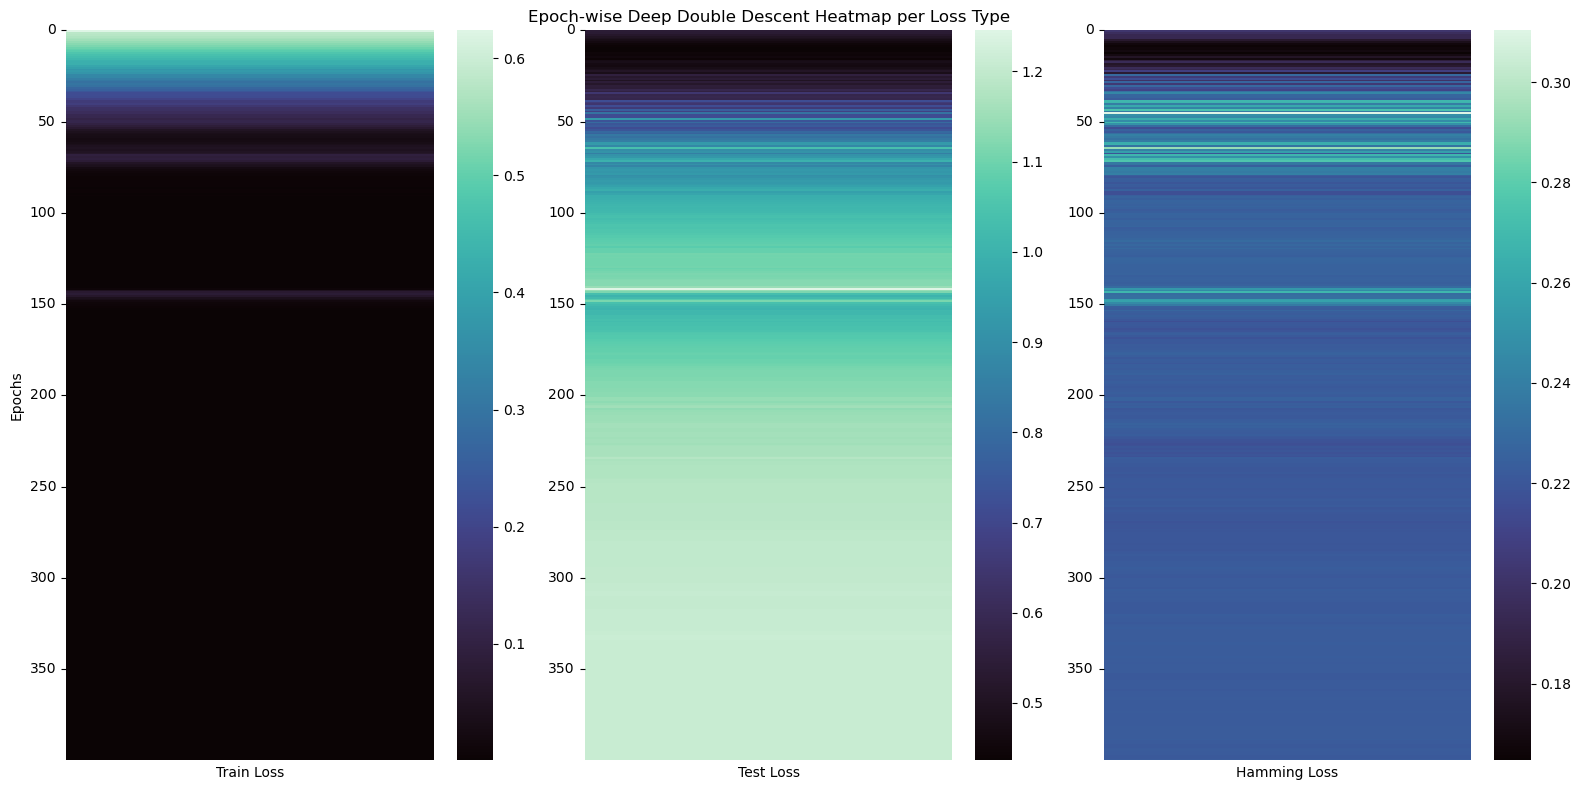

In [50]:
plot_heatmap(history=history, title_suffix = "Heatmap per Loss Type")

**_From the above plots it is apparent that the model intially performed well, then struggled then performed well again till it plateued for a longer time. This is plausible display of epoch-wise deep double descent._**